# Part 1: Basic SIR model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

rng = np.random.default_rng(42)

DISEASES = {
    "COVID-19": dict(beta=0.25, gamma=0.10),
    "Seasonal Influenza": dict(beta=0.50, gamma=0.33),
    "Ebola": dict(beta=0.15, gamma=0.10),
}

In [2]:
def simulate_sir_ctmc(N, beta, gamma, I0, R0=0, t_max=150, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    S = N - I0 - R0
    I = I0
    R = R0
    times = [0.0]
    Ss = [S]
    Is = [I]
    Rs = [R]
    t = 0.0
    while I > 0 and t < t_max:
        inf = beta * S * I / N
        rec = gamma * I
        total = inf + rec
        if total == 0:
            break
        t += rng.exponential(1.0 / total)
        if t > t_max:
            break
        if rng.random() < inf / total:
            S -= 1
            I += 1
        else:
            I -= 1
            R += 1
        times.append(t)
        Ss.append(S)
        Is.append(I)
        Rs.append(R)
    return np.array(times), np.array(Ss), np.array(Is), np.array(Rs)


def sir_ode(N, beta, gamma, I0, t_max):
    def f(t, y):
        S, I, R = y
        return [-beta * S * I / N, beta * S * I / N - gamma * I, gamma * I]
    t_eval = np.linspace(0, t_max, 600)
    sol = solve_ivp(f, (0, t_max), [N - I0, I0, 0], t_eval=t_eval)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

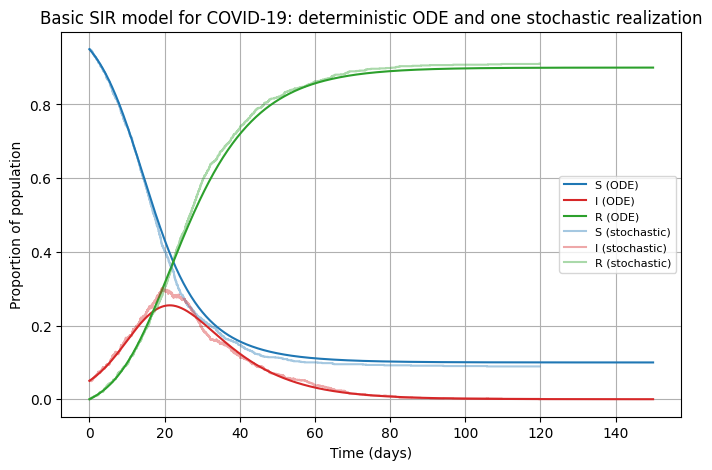

In [3]:
N = 1000
I0 = int(0.05 * N)
t_max = 150
b = DISEASES["COVID-19"]["beta"]
g = DISEASES["COVID-19"]["gamma"]
to, So, Io, Ro = sir_ode(N, b, g, I0, t_max)
tt, S, I, R = simulate_sir_ctmc(N, b, g, I0, t_max=t_max, rng=rng)

plt.figure(figsize=(8, 5))
for vals, lab, col in [(So, "S", "tab:blue"), (Io, "I", "tab:red"), (Ro, "R", "tab:green")]:
    plt.plot(to, vals / N, color=col, label=f"{lab} (ODE)")
for vals, lab, col in [(S, "S", "tab:blue"), (I, "I", "tab:red"), (R, "R", "tab:green")]:
    plt.step(tt, vals / N, where="post", color=col, alpha=0.4, label=f"{lab} (stochastic)")
plt.xlabel("Time (days)")
plt.ylabel("Proportion of population")
plt.title("Basic SIR model for COVID-19: deterministic ODE and one stochastic realization")
plt.legend(fontsize=8)
plt.grid()
plt.show()

# Part 2 (c): Spatial distribution of persons with state-dependent movement

## Spatial model

In [4]:
def simulate_spatial_sir(N, beta, gamma, L, m_heal, m_inf, I0, t_max, rng,
                         global_mix=False, snapshot_times=None):
    x = rng.integers(0, L, size=N)
    y = rng.integers(0, L, size=N)
    st = np.zeros(N, dtype=np.int64)
    cx = L // 2
    cy = L // 2
    seed = rng.choice(N, size=I0, replace=False)
    x[seed] = (cx + rng.integers(-2, 3, size=I0)) % L
    y[seed] = (cy + rng.integers(-2, 3, size=I0)) % L
    st[seed] = 1

    def neigh_sum(grid):
        s = np.zeros_like(grid)
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                s += np.roll(np.roll(grid, dx, axis=0), dy, axis=1)
        return s

    t = 0.0
    times = [0.0]
    Ss = [int((st == 0).sum())]
    Is = [int((st == 1).sum())]
    Rs = [int((st == 2).sum())]
    snaps = []
    snap_i = 0
    while True:
        nS = int((st == 0).sum())
        nI = int((st == 1).sum())
        nR = int((st == 2).sum())
        if snapshot_times is not None:
            while snap_i < len(snapshot_times) and t >= snapshot_times[snap_i]:
                snaps.append((x.copy(), y.copy(), st.copy(), snapshot_times[snap_i]))
                snap_i += 1
        if nI == 0 or t >= t_max:
            break
        if global_mix:
            inf_total = beta * nS * nI / N
            rate_cell = None
        else:
            cI = np.zeros((L, L))
            cT = np.zeros((L, L))
            cS = np.zeros((L, L))
            np.add.at(cT, (x, y), 1)
            np.add.at(cI, (x[st == 1], y[st == 1]), 1)
            np.add.at(cS, (x[st == 0], y[st == 0]), 1)
            Ih = neigh_sum(cI)
            Nh = neigh_sum(cT)
            with np.errstate(divide="ignore", invalid="ignore"):
                rate_cell = np.where(Nh > 0, cS * Ih / Nh, 0.0)
            inf_total = beta * rate_cell.sum()
        rec_total = gamma * nI
        move_total = m_heal * (nS + nR) + m_inf * nI
        total = inf_total + rec_total + move_total
        if total <= 0:
            break
        t += rng.exponential(1.0 / total)
        if t > t_max:
            break
        u = rng.random() * total
        if u < inf_total:
            if global_mix:
                cand = np.where(st == 0)[0]
            else:
                flat = rate_cell.ravel()
                ci = rng.choice(flat.size, p=flat / flat.sum())
                gx, gy = divmod(ci, L)
                cand = np.where((st == 0) & (x == gx) & (y == gy))[0]
            st[cand[rng.integers(cand.size)]] = 1
        elif u < inf_total + rec_total:
            cand = np.where(st == 1)[0]
            st[cand[rng.integers(cand.size)]] = 2
        else:
            w = np.array([m_heal * nS, m_inf * nI, m_heal * nR], dtype=float)
            k = rng.choice(3, p=w / w.sum())
            cand = np.where(st == k)[0]
            j = cand[rng.integers(cand.size)]
            d = rng.integers(4)
            if d == 0:
                x[j] = (x[j] + 1) % L
            elif d == 1:
                x[j] = (x[j] - 1) % L
            elif d == 2:
                y[j] = (y[j] + 1) % L
            else:
                y[j] = (y[j] - 1) % L
        times.append(t)
        Ss.append(int((st == 0).sum()))
        Is.append(int((st == 1).sum()))
        Rs.append(int((st == 2).sum()))
    return np.array(times), np.array(Ss), np.array(Is), np.array(Rs), snaps

In [5]:
def sample_on_grid(times, vals, t_grid):
    idx = np.searchsorted(times, t_grid, side="right") - 1
    idx = np.clip(idx, 0, len(vals) - 1)
    return vals[idx]

## Validation

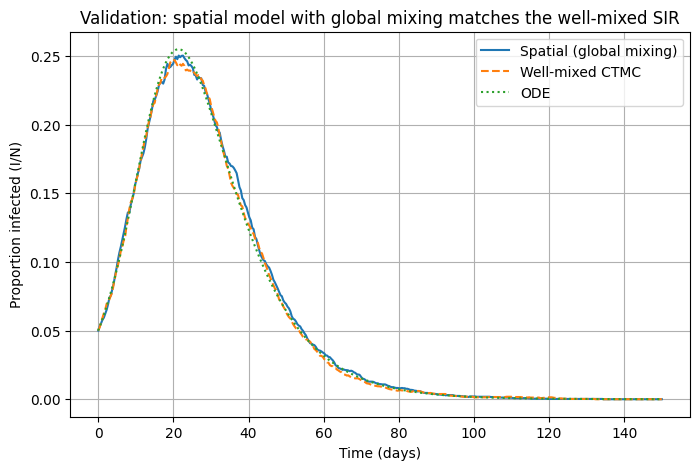

In [6]:
N = 1000
L = 30
t_max = 150
I0 = int(0.05 * N)
runs = 5
b = DISEASES["COVID-19"]["beta"]
g = DISEASES["COVID-19"]["gamma"]
tg = np.linspace(0, t_max, 400)

sp = np.zeros((runs, tg.size))
wm = np.zeros((runs, tg.size))
for r in range(runs):
    tt, S, I, R, _ = simulate_spatial_sir(N, b, g, L, 0.5, 0.5, I0, t_max, rng, global_mix=True)
    sp[r] = sample_on_grid(tt, I, tg)
    tt2, S2, I2, R2 = simulate_sir_ctmc(N, b, g, I0, t_max=t_max, rng=rng)
    wm[r] = sample_on_grid(tt2, I2, tg)
to, So, Io, Ro = sir_ode(N, b, g, I0, t_max)

plt.figure(figsize=(8, 5))
plt.plot(tg, sp.mean(0) / N, label="Spatial (global mixing)")
plt.plot(tg, wm.mean(0) / N, "--", label="Well-mixed CTMC")
plt.plot(to, Io / N, ":", label="ODE")
plt.xlabel("Time (days)")
plt.ylabel("Proportion infected (I/N)")
plt.title("Validation: spatial model with global mixing matches the well-mixed SIR")
plt.legend()
plt.grid()
plt.show()

## Spatial spread

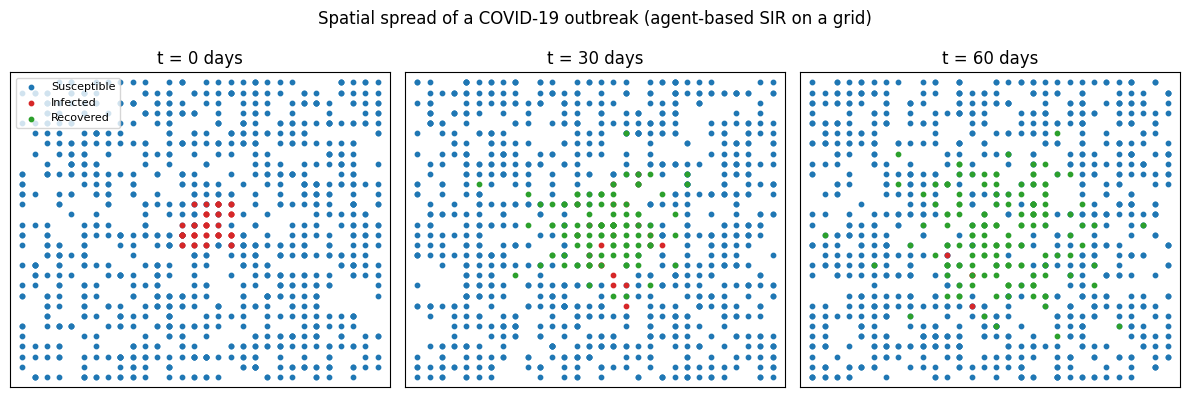

In [7]:
N = 1000
L = 30
I0 = int(0.05 * N)
b = DISEASES["COVID-19"]["beta"]
g = DISEASES["COVID-19"]["gamma"]
snap_t = [0, 30, 60, 150]
res = simulate_spatial_sir(N, b, g, L, 0.5, 0.1, I0, 150, rng, snapshot_times=snap_t)
snaps = res[4]
colors = {0: "tab:blue", 1: "tab:red", 2: "tab:green"}
labels = {0: "Susceptible", 1: "Infected", 2: "Recovered"}

fig, axes = plt.subplots(1, len(snaps), figsize=(4 * len(snaps), 4))
for ax, (sx, sy, sst, tt) in zip(axes, snaps):
    for k in (0, 1, 2):
        m = sst == k
        ax.scatter(sx[m], sy[m], s=10, c=colors[k], label=labels[k])
    ax.set_title(f"t = {tt:.0f} days")
    ax.set_xlim(-1, L)
    ax.set_ylim(-1, L)
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Spatial spread of a COVID-19 outbreak (agent-based SIR on a grid)")
plt.tight_layout()
plt.show()

## Spatial versus well-mixed

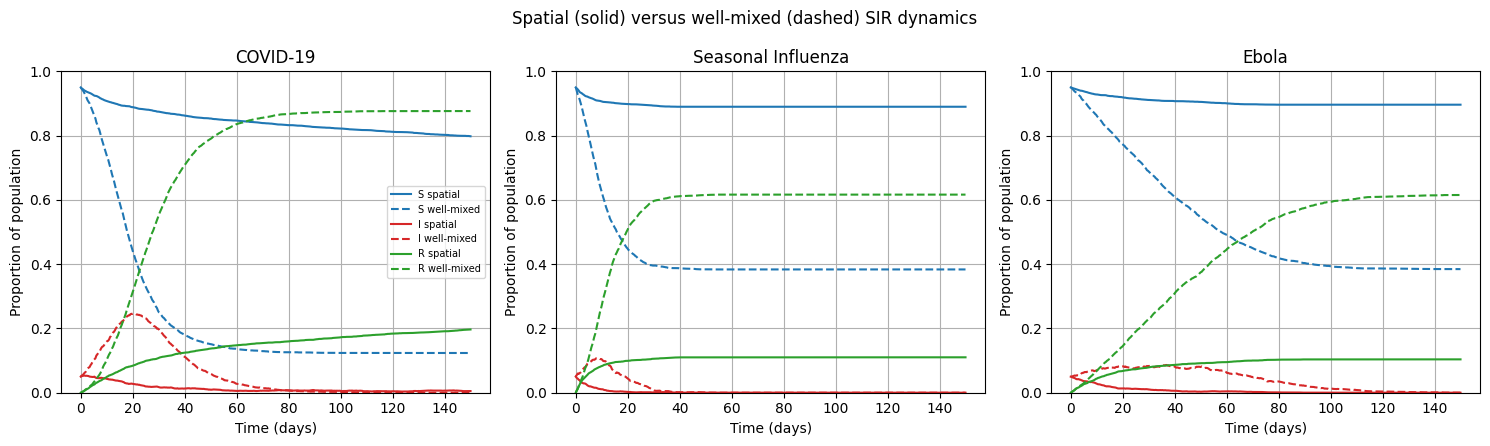

In [8]:
N = 1000
L = 30
I0 = int(0.05 * N)
t_max = 150
runs = 5
tg = np.linspace(0, t_max, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pars) in zip(axes, DISEASES.items()):
    b = pars["beta"]
    g = pars["gamma"]
    sp = np.zeros((runs, 3, tg.size))
    wm = np.zeros((runs, 3, tg.size))
    for r in range(runs):
        tt, S, I, R, _ = simulate_spatial_sir(N, b, g, L, 0.5, 0.1, I0, t_max, rng)
        sp[r] = [sample_on_grid(tt, S, tg), sample_on_grid(tt, I, tg), sample_on_grid(tt, R, tg)]
        tt2, S2, I2, R2 = simulate_sir_ctmc(N, b, g, I0, t_max=t_max, rng=rng)
        wm[r] = [sample_on_grid(tt2, S2, tg), sample_on_grid(tt2, I2, tg), sample_on_grid(tt2, R2, tg)]
    spm = sp.mean(0) / N
    wmm = wm.mean(0) / N
    for i, (lab, col) in enumerate([("S", "tab:blue"), ("I", "tab:red"), ("R", "tab:green")]):
        ax.plot(tg, spm[i], color=col, label=f"{lab} spatial")
        ax.plot(tg, wmm[i], "--", color=col, label=f"{lab} well-mixed")
    ax.set_title(name)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Proportion of population")
    ax.set_ylim(0, 1)
    ax.grid()
axes[0].legend(fontsize=7)
fig.suptitle("Spatial (solid) versus well-mixed (dashed) SIR dynamics")
plt.tight_layout()
plt.show()

## Effect of the movement rule

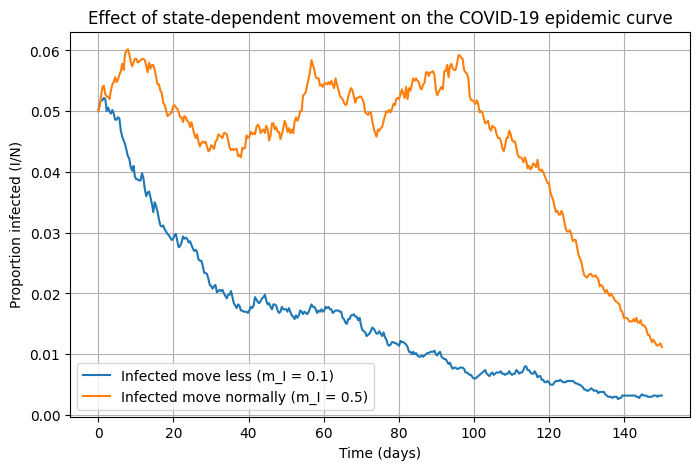

In [9]:
N = 1000
L = 30
I0 = int(0.05 * N)
t_max = 150
runs = 5
b = DISEASES["COVID-19"]["beta"]
g = DISEASES["COVID-19"]["gamma"]
tg = np.linspace(0, t_max, 400)


def mean_I(m_inf):
    out = np.zeros((runs, tg.size))
    for r in range(runs):
        tt, S, I, R, _ = simulate_spatial_sir(N, b, g, L, 0.5, m_inf, I0, t_max, rng)
        out[r] = sample_on_grid(tt, I, tg)
    return out.mean(0) / N


less = mean_I(0.1)
normal = mean_I(0.5)
plt.figure(figsize=(8, 5))
plt.plot(tg, less, label="Infected move less (m_I = 0.1)")
plt.plot(tg, normal, label="Infected move normally (m_I = 0.5)")
plt.xlabel("Time (days)")
plt.ylabel("Proportion infected (I/N)")
plt.title("Effect of state-dependent movement on the COVID-19 epidemic curve")
plt.legend()
plt.grid()
plt.show()